In [ ]:
# -- Neccessary Imports --
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

# Show all columns when printing dataframes
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)  

import sys
import os
sys.path.insert(0, os.path.abspath(".."))

In [2]:
# -- Load the training dataset --
df = pd.read_csv("../data/raw/cs-training.csv", index_col=0)
print(f"Shape: {df.shape}")
df.head()

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


In [3]:
# -- Rename columns for better readability and consistent snake_case --
COLUMN_MAP = {
    "SeriousDlqin2yrs": "target",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_util",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "dpd_30_59",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "open_credit_lines",
    "NumberOfTimes90DaysLate": "dpd_90_plus",
    "NumberRealEstateLoansOrLines": "real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "dpd_60_89",
    "NumberOfDependents": "n_dependents",
}

df = df.rename(columns=COLUMN_MAP)
df.columns.tolist()

['target',
 'revolving_util',
 'age',
 'dpd_30_59',
 'debt_ratio',
 'monthly_income',
 'open_credit_lines',
 'dpd_90_plus',
 'real_estate_loans',
 'dpd_60_89',
 'n_dependents']

In [4]:
df.head()

,target,revolving_util,age,dpd_30_59,debt_ratio,monthly_income,open_credit_lines,dpd_90_plus,real_estate_loans,dpd_60_89,n_dependents
1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


In [5]:
# -- Re-order the columns --
COLUMN_ORDER = [
    "age",
    "monthly_income",
    "debt_ratio",
    "revolving_util",
    "open_credit_lines",
    "real_estate_loans",
    "n_dependents",
    "dpd_30_59",
    "dpd_60_89",
    "dpd_90_plus",
    "target",
]

df = df[COLUMN_ORDER]
df.head()

,age,monthly_income,debt_ratio,revolving_util,open_credit_lines,real_estate_loans,n_dependents,dpd_30_59,dpd_60_89,dpd_90_plus,target
1,45,9120.00,0.80,0.77,13,6,2.00,2,0,0,1
2,40,2600.00,0.12,0.96,4,0,1.00,0,0,0,0
3,38,3042.00,0.09,0.66,2,0,0.00,1,0,1,0
4,30,3300.00,0.04,0.23,5,0,0.00,0,0,0,0
5,49,63588.00,0.02,0.91,7,1,0.00,1,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   age                150000 non-null  int64  
 1   monthly_income     120269 non-null  float64
 2   debt_ratio         150000 non-null  float64
 3   revolving_util     150000 non-null  float64
 4   open_credit_lines  150000 non-null  int64  
 5   real_estate_loans  150000 non-null  int64  
 6   n_dependents       146076 non-null  float64
 7   dpd_30_59          150000 non-null  int64  
 8   dpd_60_89          150000 non-null  int64  
 9   dpd_90_plus        150000 non-null  int64  
 10  target             150000 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,150000.00,52.30,14.77,0.00,41.00,52.00,63.00,109.00
monthly_income,120269.00,6670.22,14384.67,0.00,3400.00,5400.00,8249.00,3008750.00
debt_ratio,150000.00,353.01,2037.82,0.00,0.18,0.37,0.87,329664.00
revolving_util,150000.00,6.05,249.76,0.00,0.03,0.15,0.56,50708.00
open_credit_lines,150000.00,8.45,5.15,0.00,5.00,8.00,11.00,58.00
real_estate_loans,150000.00,1.02,1.13,0.00,0.00,1.00,2.00,54.00
n_dependents,146076.00,0.76,1.12,0.00,0.00,0.00,1.00,20.00
dpd_30_59,150000.00,0.42,4.19,0.00,0.00,0.00,0.00,98.00
dpd_60_89,150000.00,0.24,4.16,0.00,0.00,0.00,0.00,98.00
dpd_90_plus,150000.00,0.27,4.17,0.00,0.00,0.00,0.00,98.00


### EDA - Target Distribution

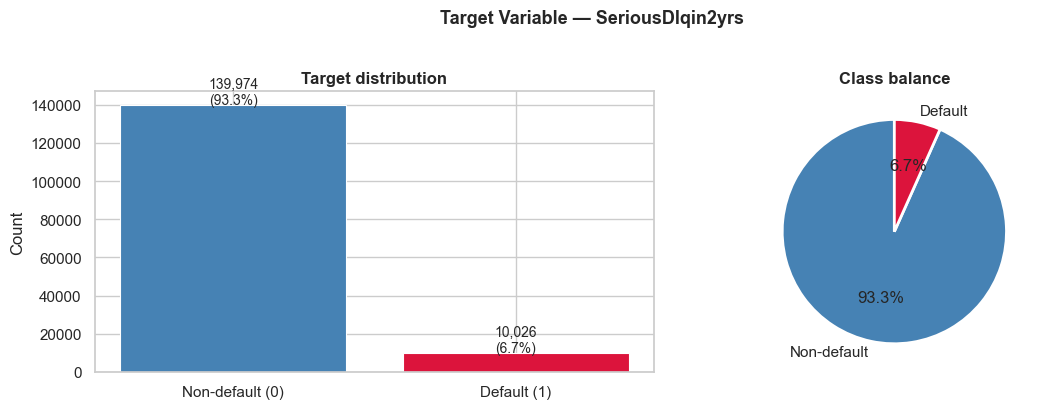

Default rate: 6.68%
Class imbalance ratio: 14.0:1


In [8]:
# -- Visualize Target Distribution --

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
target_counts = df["target"].value_counts()
axes[0].bar(["Non-default (0)", "Default (1)"], target_counts.values, 
            color=["steelblue", "crimson"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Target distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f"{v:,}\n({v/len(df)*100:.1f}%)", 
                ha="center", fontsize=10)

# Imbalance ratio
axes[1].pie(target_counts.values, labels=["Non-default", "Default"],
            colors=["steelblue", "crimson"], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class balance", fontweight="bold")

plt.suptitle("Target Variable — SeriousDlqin2yrs", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Default rate: {df['target'].mean():.2%}")
print(f"Class imbalance ratio: {(1 - df['target'].mean()) / df['target'].mean():.1f}:1")

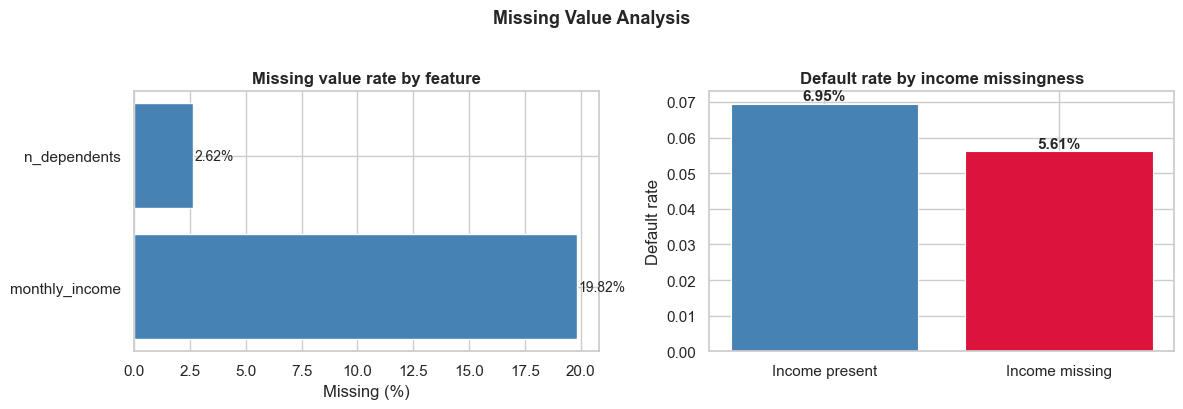

KeyError: "['age_missing'] not found in axis"

In [9]:
# -- Analyze Missing Values --
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Missing value counts
missing = df.isnull().sum()
missing = missing[missing > 0]
pct = (missing / len(df) * 100).round(2)

axes[0].barh(missing.index, pct.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Missing (%)")
axes[0].set_title("Missing value rate by feature", fontweight="bold")
for i, v in enumerate(pct.values):
    axes[0].text(v + 0.1, i, f"{v}%", va="center", fontsize=10)

# Is missingness related to default?
df["income_missing"] = df["monthly_income"].isnull().astype(int)
miss_default = df.groupby("income_missing")["target"].mean()
axes[1].bar(["Income present", "Income missing"], miss_default.values,
            color=["steelblue", "crimson"], edgecolor="white", linewidth=0.8)
axes[1].set_ylabel("Default rate")
axes[1].set_title("Default rate by income missingness", fontweight="bold")
for i, v in enumerate(miss_default.values):
    axes[1].text(i, v + 0.001, f"{v:.2%}", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Missing Value Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Clean up helper columns
df = df.drop(columns=["income_missing", "age_missing"])

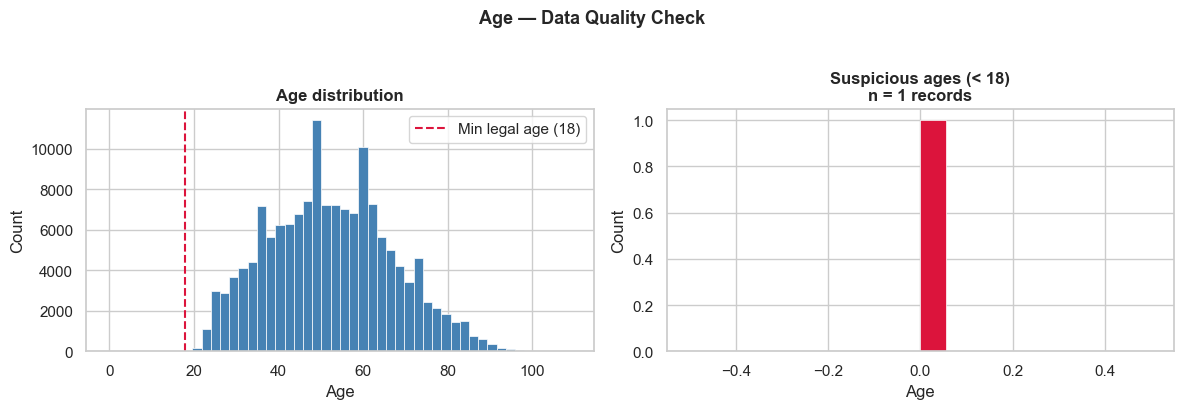

Records with age = 0: 1
Records with age < 18: 1
Records with age > 100: 13

Age value counts for age < 18:
age
0    1
Name: count, dtype: int64


In [10]:
# -- Analyze Age Distribution and Data Quality --
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full age distribution
axes[0].hist(df["age"], bins=50, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_title("Age distribution", fontweight="bold")
axes[0].axvline(18, color="crimson", linestyle="--", linewidth=1.5, label="Min legal age (18)")
axes[0].legend()

# Zoom into suspicious values
suspicious_age = df[df["age"] < 18]
axes[1].hist(df[df["age"] < 18]["age"], bins=18, color="crimson", 
             edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Suspicious ages (< 18)\nn = {len(suspicious_age):,} records", 
                  fontweight="bold")

plt.suptitle("Age — Data Quality Check", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Records with age = 0: {(df['age'] == 0).sum()}")
print(f"Records with age < 18: {(df['age'] < 18).sum()}")
print(f"Records with age > 100: {(df['age'] > 100).sum()}")
print(f"\nAge value counts for age < 18:\n{df[df['age'] < 18]['age'].value_counts().sort_index()}")

Revolving utilisation — extreme value breakdown:
  Values <= 1 (within limit):    146,679
  Values > 1 (over limit):    3,321
  Values > 2:                 371
  Values > 5:                 254
  Values > 10:                241
  Values > 100:               223

Top 10 extreme values:
[50708. 29110. 22198. 22000. 20514. 18300. 17441. 13930. 13498. 13400.]


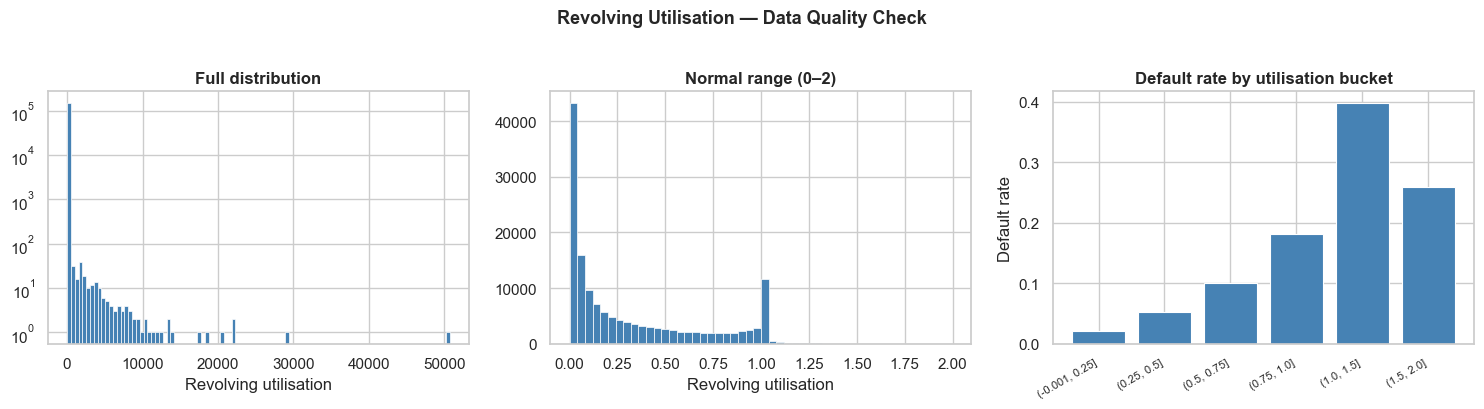

In [11]:
# -- Analyze Revolving Utilisation Distribution and Data Quality --
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full distribution (log scale to see the extreme tail)
axes[0].hist(df["revolving_util"], bins=100, color="steelblue", 
             edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Revolving utilisation")
axes[0].set_title("Full distribution", fontweight="bold")
axes[0].set_yscale("log")

# Zoomed in to 0-2 (normal range)
normal = df[df["revolving_util"] <= 2]
axes[1].hist(normal["revolving_util"], bins=50, color="steelblue",
             edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Revolving utilisation")
axes[1].set_title("Normal range (0–2)", fontweight="bold")

# Extreme values
print("Revolving utilisation — extreme value breakdown:")
print(f"  Values <= 1 (within limit):    {(df['revolving_util'] <= 1).sum():,}")
print(f"  Values > 1 (over limit):    {(df['revolving_util'] > 1).sum():,}")
print(f"  Values > 2:                 {(df['revolving_util'] > 2).sum():,}")
print(f"  Values > 5:                 {(df['revolving_util'] > 5).sum():,}")
print(f"  Values > 10:                {(df['revolving_util'] > 10).sum():,}")
print(f"  Values > 100:               {(df['revolving_util'] > 100).sum():,}")
print(f"\nTop 10 extreme values:")
print(df["revolving_util"].nlargest(10).values)

# Default rate by utilisation bucket
buckets = pd.cut(df["revolving_util"].clip(upper=2), 
                 bins=[0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0],
                 include_lowest=True)
default_by_bucket = df.groupby(buckets, observed=True)["target"].mean()
axes[2].bar(range(len(default_by_bucket)), default_by_bucket.values,
            color="steelblue", edgecolor="white", linewidth=0.8)
axes[2].set_xticks(range(len(default_by_bucket)))
axes[2].set_xticklabels([str(b) for b in default_by_bucket.index], 
                         rotation=30, ha="right", fontsize=8)
axes[2].set_ylabel("Default rate")
axes[2].set_title("Default rate by utilisation bucket", fontweight="bold")

plt.suptitle("Revolving Utilisation — Data Quality Check", 
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

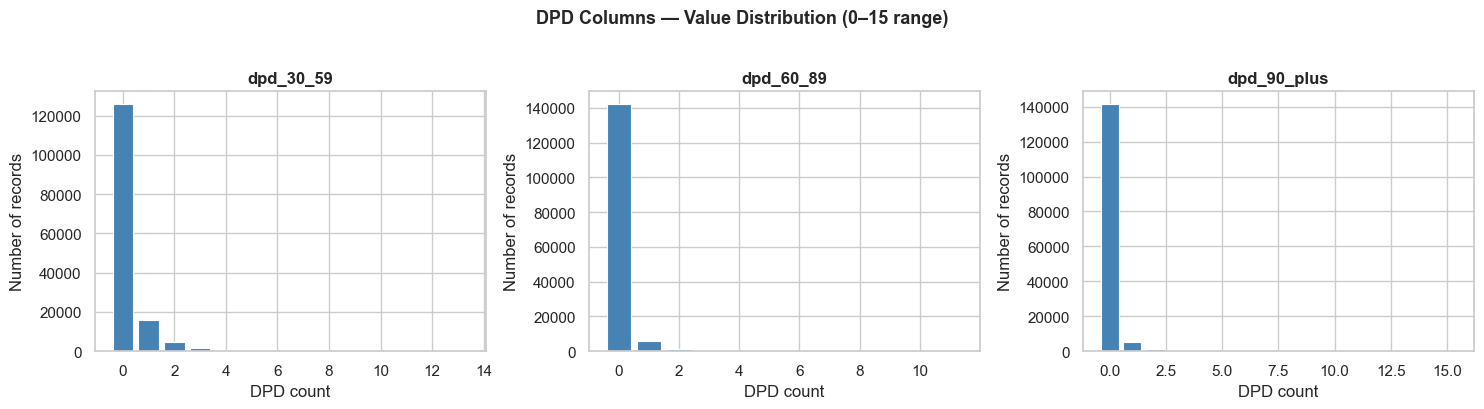

Sentinel value counts (96 and 98):
  dpd_30_59: 96 → 5 records | 98 → 264 records
  dpd_60_89: 96 → 5 records | 98 → 264 records
  dpd_90_plus: 96 → 5 records | 98 → 264 records

Records where ANY DPD column has sentinel value:
  269 records (0.18%)

Default rate for sentinel records: 54.65%
Default rate for clean records:   6.60%


In [12]:
# -- Analyze DPD Columns and Sentinel Values --
dpd_cols = ["dpd_30_59", "dpd_60_89", "dpd_90_plus"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(dpd_cols):
    value_counts = df[col].value_counts().sort_index()
    # Clip to show 0-15 range clearly
    normal_counts = value_counts[value_counts.index <= 15]
    axes[i].bar(normal_counts.index, normal_counts.values, 
                color="steelblue", edgecolor="white", linewidth=0.8)
    axes[i].set_xlabel("DPD count")
    axes[i].set_ylabel("Number of records")
    axes[i].set_title(col, fontweight="bold")

plt.suptitle("DPD Columns — Value Distribution (0–15 range)", 
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Sentinel value counts (96 and 98):")
for col in dpd_cols:
    n_96 = (df[col] == 96).sum()
    n_98 = (df[col] == 98).sum()
    print(f"  {col}: 96 → {n_96:,} records | 98 → {n_98:,} records")

print(f"\nRecords where ANY DPD column has sentinel value:")
sentinel_mask = (df[dpd_cols] >= 90).any(axis=1)
print(f"  {sentinel_mask.sum():,} records ({sentinel_mask.mean():.2%})")

print(f"\nDefault rate for sentinel records: {df[sentinel_mask]['target'].mean():.2%}")
print(f"Default rate for clean records:   {df[~sentinel_mask]['target'].mean():.2%}")

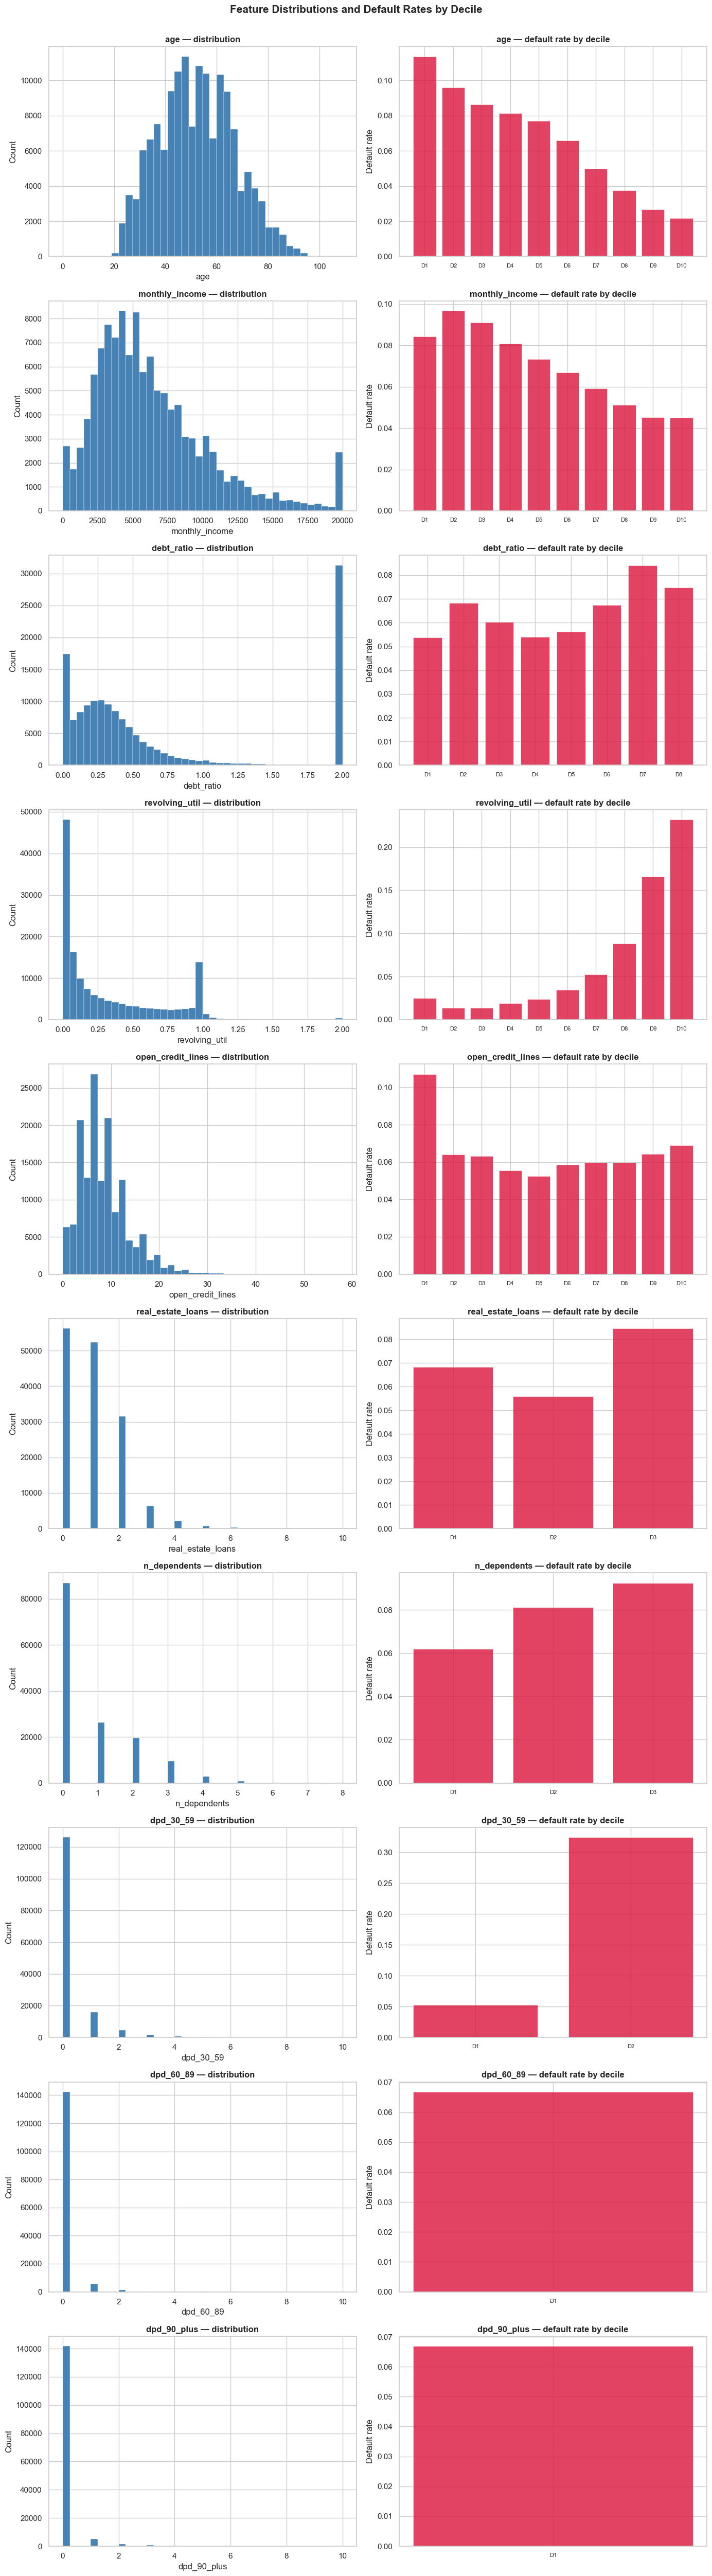

In [13]:
# -- Analyze Feature Distributions and Default Rates --
features = [
    "age", "monthly_income", "debt_ratio", "revolving_util",
    "open_credit_lines", "real_estate_loans", "n_dependents",
    "dpd_30_59", "dpd_60_89", "dpd_90_plus"
]

# Clip extreme values for visualisation only
clip_vals = {
    "monthly_income": 20000,
    "debt_ratio": 2,
    "revolving_util": 2,
    "real_estate_loans": 10,
    "n_dependents": 8,
    "dpd_30_59": 10,
    "dpd_60_89": 10,
    "dpd_90_plus": 10,
}

fig, axes = plt.subplots(len(features), 2, figsize=(14, 50))

for i, feat in enumerate(features):
    plot_series = df[feat].clip(upper=clip_vals.get(feat, df[feat].max()))

    # Left: distribution
    axes[i, 0].hist(plot_series.dropna(), bins=40,
                    color="steelblue", edgecolor="white", linewidth=0.3)
    axes[i, 0].set_title(f"{feat} — distribution", fontweight="bold")
    axes[i, 0].set_xlabel(feat)
    axes[i, 0].set_ylabel("Count")

    # Right: default rate by decile
    try:
        deciles = pd.qcut(plot_series, q=10, duplicates="drop")
        default_by_decile = df.groupby(deciles, observed=True)["target"].mean()
        axes[i, 1].bar(range(len(default_by_decile)), default_by_decile.values,
                       color="crimson", edgecolor="white", linewidth=0.5, alpha=0.8)
        axes[i, 1].set_title(f"{feat} — default rate by decile", fontweight="bold")
        axes[i, 1].set_ylabel("Default rate")
        axes[i, 1].set_xticks(range(len(default_by_decile)))
        axes[i, 1].set_xticklabels(
            [f"D{j+1}" for j in range(len(default_by_decile))],
            fontsize=8
        )
    except Exception as e:
        axes[i, 1].text(0.5, 0.5, f"Could not plot:\n{e}",
                        ha="center", va="center", transform=axes[i, 1].transAxes)

plt.suptitle("Feature Distributions and Default Rates by Decile",
             fontsize=15, fontweight="bold", y=1.001)
plt.tight_layout()
plt.show()

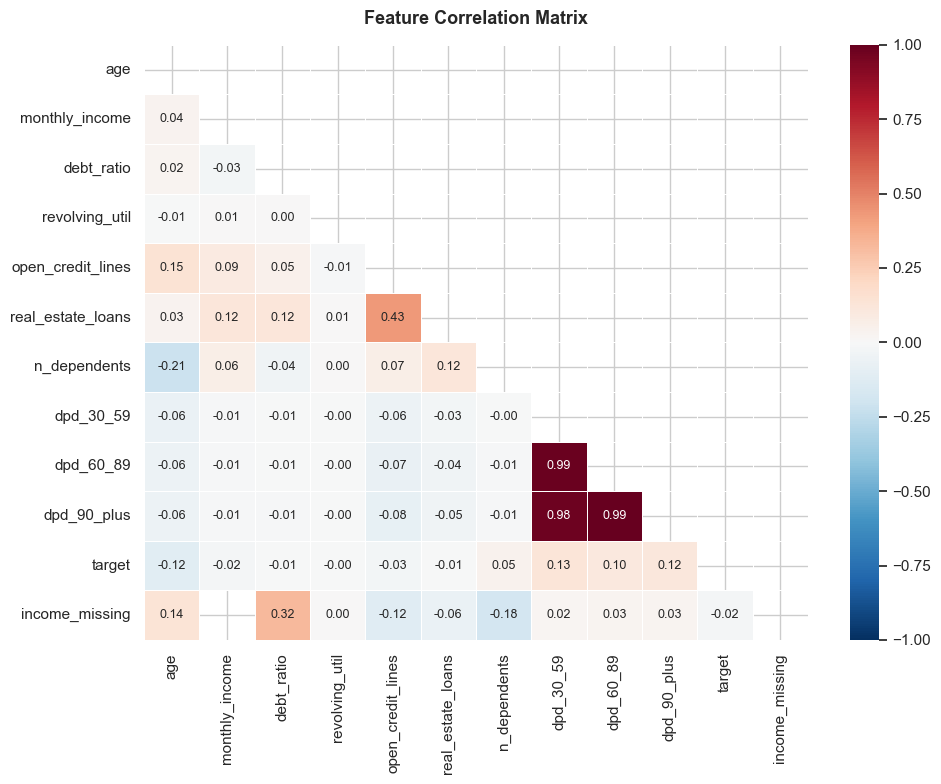

Top correlations with target:
dpd_30_59           0.13
dpd_90_plus         0.12
age                 0.12
dpd_60_89           0.10
n_dependents        0.05
open_credit_lines   0.03
income_missing      0.02
monthly_income      0.02
debt_ratio          0.01
real_estate_loans   0.01
revolving_util      0.00


In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9}
)

ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print("Top correlations with target:")
target_corr = corr_matrix["target"].drop("target").abs().sort_values(ascending=False)
print(target_corr.round(3).to_string())

## EDA Findings Summary

### Dataset
- **150,000 records**, 10 features + 1 target
- Source: Give Me Some Credit (Kaggle)

---

### Target Variable
| Metric | Value |
|---|---|
| Default rate | 6.7% |
| Non-defaults | 139,974 (93.3%) |
| Defaults | 10,026 (6.7%) |
| Class imbalance ratio | 13.9:1 |

**Implication:** Never use accuracy as an evaluation metric here. Use AUC-ROC and Gini.  
**XGBoost:** set `scale_pos_weight = 13.9` to compensate for imbalance.

---

### Data Quality Issues → actions for `cleaning.py`

| Feature | Issue | Records affected | Treatment |
|---|---|---|---|
| `age` | Values of 0 and >100 | 14 (0.009%) | Remove records |
| `revolving_util` | Values >5.0 are data errors | 254 (0.17%) | Cap at 5.0 |
| `dpd_30_59/60_89/90_plus` | Sentinel values 96 and 98 mean "unknown" | 269 (0.18%) | Cap at 10 |
| `monthly_income` | Missing | 29,731 (19.82%) | Median imputation by age decile |
| `n_dependents` | Missing | 3,924 (2.62%) | Impute with 0 |
| `n_dependents` | Wrong dtype (float64) | All rows | Cast to int64 after imputation |

> ⚠️ **Critical:** Sentinel records in DPD columns default at **54.65%** vs 6.60% baseline.
> Leaving 96/98 as real values would cause severe feature leakage.

---

### Feature Signal Assessment

| Feature | Signal strength | Relationship | Notes |
|---|---|---|---|
| `revolving_util` | * * * * * | Non-linear | Pearson=0.00 but strong visual monotonic — WoE essential |
| `dpd_30_59` | * * * * * | Non-linear | Near-binary in practice |
| `dpd_60_89` | * * * * * | Non-linear | Near-binary in practice |
| `dpd_90_plus` | * * * * * | Non-linear | Strongest severity signal |
| `age` | * * * * | Monotonic | Younger = higher risk, clean relationship |
| `monthly_income` | * * * | Monotonic | 20% missing, right-skewed |
| `debt_ratio` | * * | Noisy | Non-monotonic — corrupted when income = 0 |
| `real_estate_loans` | * * | Low cardinality | Limited signal |
| `open_credit_lines` | * | U-shaped | Effects cancel out |
| `n_dependents` | * | Non-monotonic | Weak overall |

---

### Multicollinearity

`dpd_30_59`, `dpd_60_89`, and `dpd_90_plus` are **0.98–0.99 correlated** with each other.

- **XGBoost:** no action needed — tree models handle correlated features fine
- **Logistic regression scorecard:** consider retaining only `dpd_90_plus` to avoid unstable coefficients, or accept noisy coefficients and rely on WoE binning to absorb the redundancy

---

### Key Insight

> Pearson correlation gave `revolving_util` a score of **0.00** against the target —
> yet it's visually the strongest predictor in the dataset.
>
> This is why credit risk modelling uses **Weight of Evidence (WoE) binning** rather than
> linear correlation for feature assessment. WoE captures non-linear relationships
> that Pearson misses entirely.